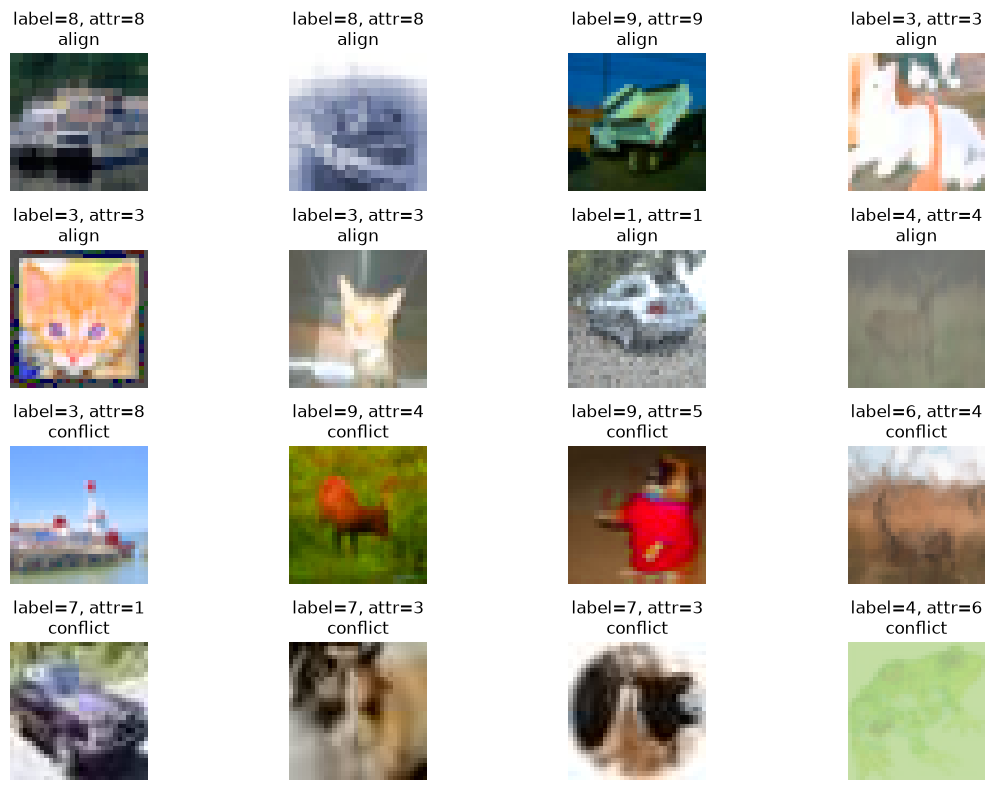

In [1]:
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image

# 테스트 이미지 경로
image_paths = glob.glob("../dataset/cifar10c/test/*/*")

# 파일명 마지막 두 숫자:
# 마지막 숫자 = 실제 클래스(label)
# 그 앞 숫자 = 색상 속성(attribute)
def get_label_attr(path):
    filename = path.replace("\\", "/").split("/")[-1]
    parts = filename.rsplit("_", 2)
    attr = int(parts[-2])
    label = int(parts[-1].split(".")[0])
    return label, attr

# align: label == attr
align_paths = [
    path for path in image_paths
    if get_label_attr(path)[0] == get_label_attr(path)[1]
]

# conflict: label != attr
conflict_paths = [
    path for path in image_paths
    if get_label_attr(path)[0] != get_label_attr(path)[1]
]

# align/conflict 각각 8장 보기
samples = random.sample(align_paths, 8) + random.sample(conflict_paths, 8)

plt.figure(figsize=(12, 8))

for i, path in enumerate(samples):
    image = Image.open(path)

    label, attr = get_label_attr(path)
    relation = "align" if label == attr else "conflict"

    plt.subplot(4, 4, i + 1)
    plt.imshow(image)
    plt.title(f"label={label}, attr={attr}\n{relation}")
    plt.axis("off")

plt.tight_layout()
plt.show()